# Task 1: Data Exploration and Preprocessing

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset.csv')

In [10]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [14]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [17]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [16]:
df['Cuisines'] = df['Cuisines'].fillna( df['Cuisines'].mode()[0])

In [18]:
df['Aggregate rating'].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

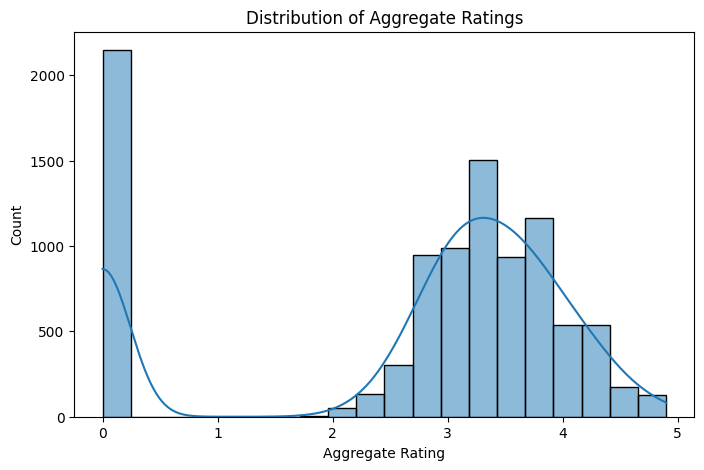

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Aggregate rating'],
    bins=20,
    kde=True)
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Count')
plt.savefig('Distribution of Aggregate Ratings.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
df['Rating text'].value_counts()
round(df['Rating text'].value_counts(normalize=True)*100,2)

Rating text
Average      39.13
Not rated    22.49
Good         21.99
Very Good    11.30
Excellent     3.15
Poor          1.95
Name: proportion, dtype: float64

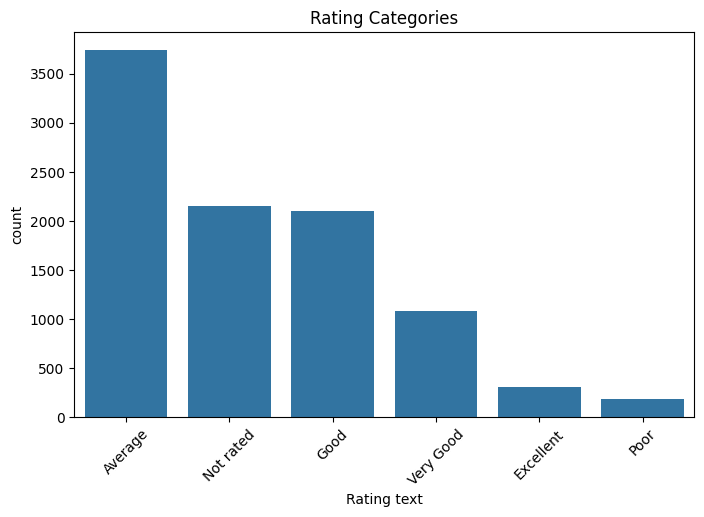

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Rating text',
    data=df,
    order=df['Rating text'].value_counts().index)

plt.xticks(rotation=45)
plt.title("Rating Categories")
plt.savefig('Rating Categories.png', dpi=300, bbox_inches='tight')
plt.show()

# Dataset Overview

The dataset contains 9,551 rows and 21 columns. It includes information about restaurants such as location, cuisines, cost, ratings, online delivery, and customer votes.

## Missing Value Analysis

The dataset was examined for missing values. Only the "Cuisines" column contained missing values (9 records). Since the number of missing values was very small, they were replaced using the most frequent cuisine (mode).

## Data Type Analysis

The dataset contains numerical and categorical variables. Numerical columns include Restaurant ID, Average Cost for Two, Aggregate Rating, Price Range, and Votes. Categorical columns include Restaurant Name, City, Currency, Rating Text, and Online Delivery status. No major data type conversion was required.

## Aggregate Rating Distribution

The target variable, "Aggregate Rating", was analyzed using descriptive statistics and visualization techniques. Most restaurants received ratings between 2.5 and 4.0. A significant number of restaurants had an aggregate rating of 0, indicating that they were not yet rated by customers.

## Class Imbalance Analysis

The distribution of rating categories is as follows:

* Average: 39.13%
* Not Rated: 22.49%
* Good: 21.99%
* Very Good: 11.30%
* Excellent: 3.15%
* Poor: 1.95%

The dataset shows class imbalance because the majority of restaurants belong to the "Average", "Not Rated", and "Good" categories, while "Excellent" and "Poor" categories contain significantly fewer observations.

## Key Findings

* Dataset contains 9,551 restaurant records.
* Only one column (Cuisines) contained missing values.
* Most restaurants are rated between 2.5 and 4.0.
* Average-rated restaurants form the largest category.
* The target variable exhibits class imbalance, which should be considered during predictive modeling.


# Basic Statistical Measures

## Mean 

In [23]:
df.mean(numeric_only=True)

Restaurant ID           9.051128e+06
Country Code            1.836562e+01
Longitude               6.412657e+01
Latitude                2.585438e+01
Average Cost for two    1.199211e+03
Price range             1.804837e+00
Aggregate rating        2.666370e+00
Votes                   1.569097e+02
dtype: float64

## Median

In [24]:
df.median(numeric_only=True)

Restaurant ID           6.004089e+06
Country Code            1.000000e+00
Longitude               7.719196e+01
Latitude                2.857047e+01
Average Cost for two    4.000000e+02
Price range             2.000000e+00
Aggregate rating        3.200000e+00
Votes                   3.100000e+01
dtype: float64

## Standard Divation

In [25]:
df.std(numeric_only=True)

Restaurant ID           8.791521e+06
Country Code            5.675055e+01
Longitude               4.146706e+01
Latitude                1.100794e+01
Average Cost for two    1.612118e+04
Price range             9.056088e-01
Aggregate rating        1.516378e+00
Votes                   4.301691e+02
dtype: float64

## Variance

In [26]:
df.var(numeric_only=True)

Restaurant ID           7.729085e+13
Country Code            3.220624e+03
Longitude               1.719517e+03
Latitude                1.211746e+02
Average Cost for two    2.598925e+08
Price range             8.201274e-01
Aggregate rating        2.299401e+00
Votes                   1.850455e+05
dtype: float64

# Distribution of Country Code

In [27]:
df['Country Code'].value_counts()

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

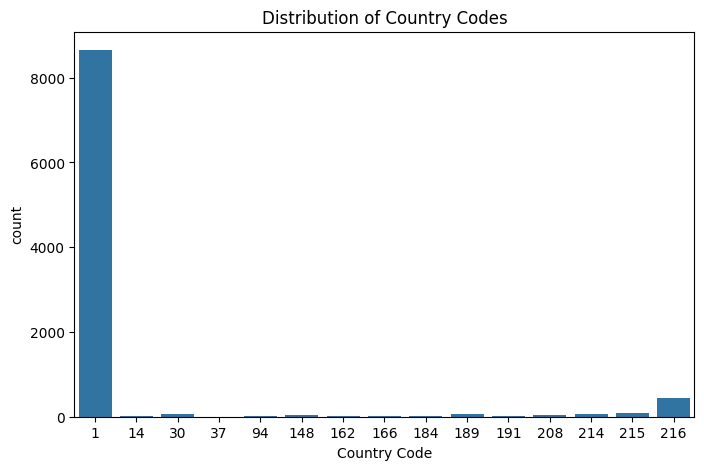

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Country Code', data=df)

plt.title("Distribution of Country Codes")
plt.savefig('Distribution of Country Codes.png', dpi=300, bbox_inches='tight')
plt.show()

# Distribution of Cities

In [29]:
df['City'].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

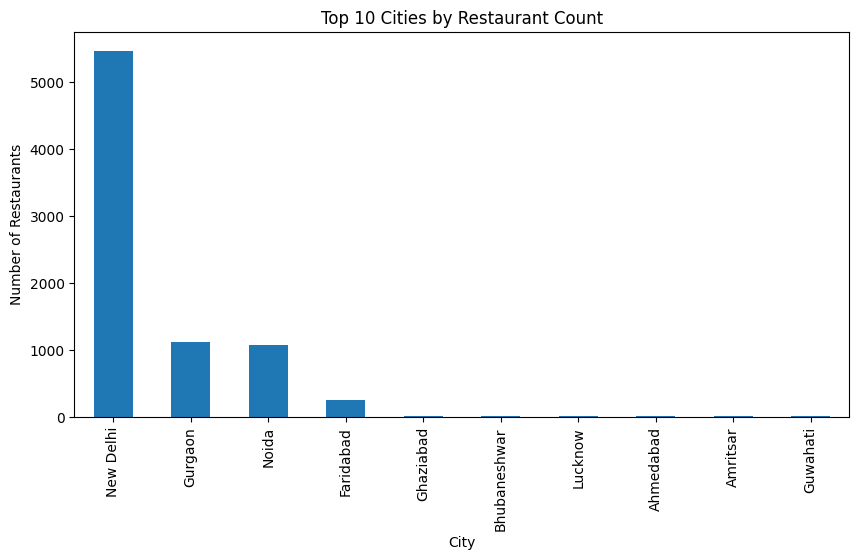

In [28]:
plt.figure(figsize=(10,5))

df['City'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Cities by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.savefig('Top 10 Cities by Restaurant Count.png', dpi=300, bbox_inches='tight')
plt.show()

# Distribution of Cuisines

In [ ]:
df['Cuisines'].value_counts().head(10)

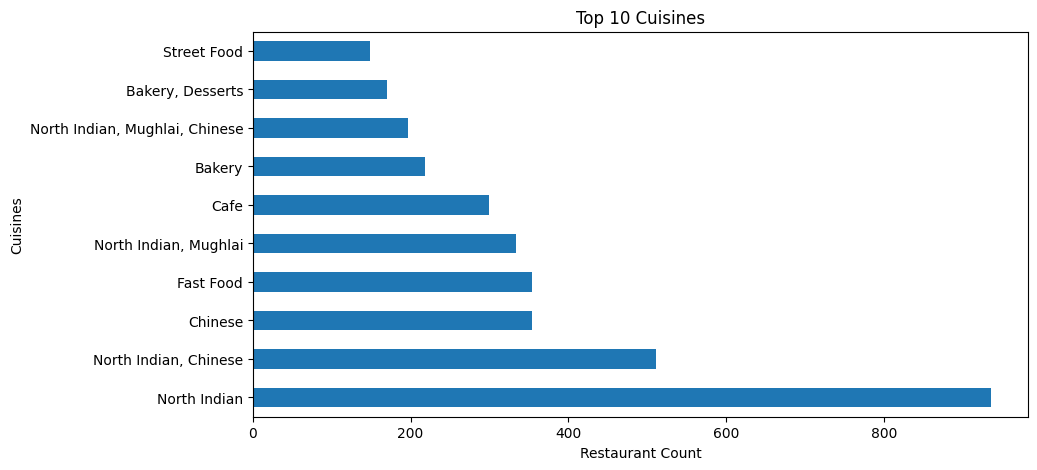

In [29]:
plt.figure(figsize=(10,5))

df['Cuisines'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Cuisines")
plt.xlabel("Restaurant Count")
plt.savefig('Top 10 Cuisines.png', dpi=300, bbox_inches='tight')
plt.show()

# Top Cities with Highest Restaurants

In [32]:
top_cities = df['City'].value_counts().head(10)
print(top_cities)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


# Top Cuisines with Highest Restaurants

In [33]:
top_cuisines = df['Cuisines'].value_counts().head(10)
print(top_cuisines)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


# Task 2: Descriptive Analysis

## Statistical Analysis

Descriptive statistics were calculated for numerical columns such as Aggregate Rating, Average Cost for Two, Votes, Latitude, and Longitude. Measures including mean, median, standard deviation, minimum, and maximum values were used to understand the central tendency and spread of the data.

## Distribution of Categorical Variables

### Country Code

The majority of restaurants belong to a single country code, indicating that the dataset is primarily concentrated in one country.

### City Distribution

Restaurant distribution is highly concentrated in a few cities. New Delhi contains the highest number of restaurants (5473), followed by Gurgaon (1118) and Noida (1080).

### Cuisine Distribution

North Indian cuisine is the most common cuisine category with 936 restaurants. Other popular cuisines include North Indian & Chinese, Chinese, Fast Food, and North Indian & Mughlai.

## Top Cities by Restaurant Count

1. New Delhi – 5473
2. Gurgaon – 1118
3. Noida – 1080
4. Faridabad – 251
5. Ghaziabad – 25

## Top Cuisines

1. North Indian – 936
2. North Indian, Chinese – 511
3. Chinese – 354
4. Fast Food – 354
5. North Indian, Mughlai – 334

## Key Findings

* The restaurant market is heavily concentrated in the Delhi NCR region.
* North Indian cuisine is the most popular cuisine category.
* Chinese cuisine is frequently combined with North Indian cuisine.
* Fast Food, Cafes, and Bakeries represent important segments of the restaurant industry.
* The dataset shows strong geographic concentration and cuisine preferences.


# Restaurant Locations on Map

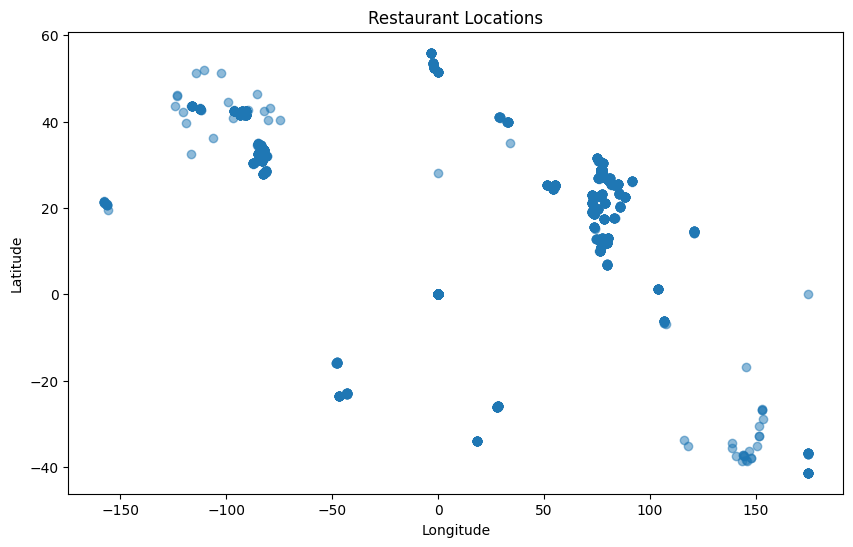

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig('Restaurant Locations.png', dpi=300, bbox_inches='tight')
plt.show()

## Insights 

The scatter plot visualizes restaurant locations using latitude and longitude coordinates. Restaurant locations form several clusters, indicating that restaurants are concentrated in specific cities and urban regions rather than being evenly distributed. This suggests higher business activity and customer demand in metropolitan areas.

# 3. Rating vs Location

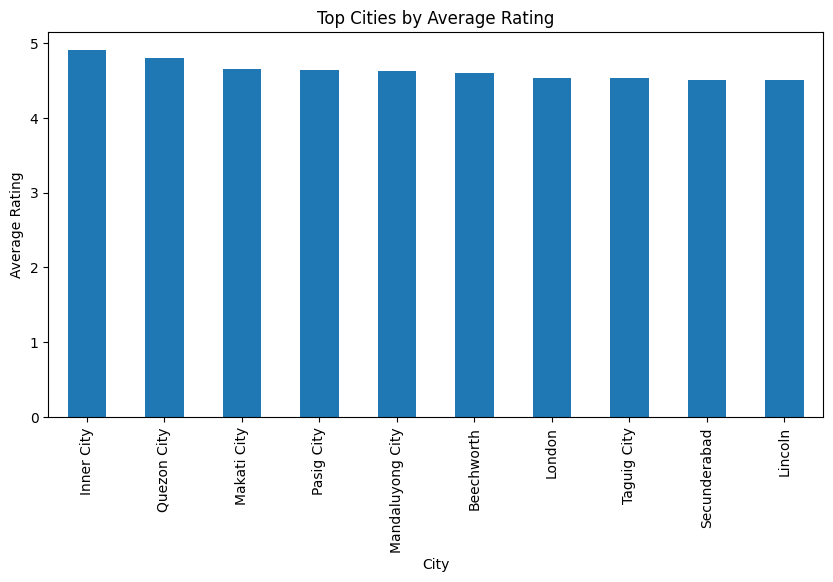

In [31]:
city_rating = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
city_rating.plot(kind='bar')

plt.title('Top Cities by Average Rating')
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.savefig('Top Cities by Average Rating.png', dpi=300, bbox_inches='tight')
plt.show()

### Insights
The average rating differs across cities. Cities such as Inner City, Quezon City, and Makati City have higher average ratings. This indicates that restaurant performance and customer satisfaction may vary by location.

## Geospatial Analysis Conclusion
The geospatial analysis of restaurant data was performed using latitude and longitude coordinates. A scatter plot was used to visualize restaurant locations, revealing clusters in major urban regions. Restaurant distribution analysis showed that certain cities contain a much higher number of restaurants than others. Additionally, average restaurant ratings vary across cities, indicating that location may have some influence on customer satisfaction. Overall, restaurants are concentrated in urban areas, and location appears to play a role in restaurant performance, although other factors such as cuisine, service quality, and pricing may also affect ratings.


# Table Booking and Online Delivery
## Percentage of Restaurants Offering Table Booking

In [7]:
table_booking_percent = (df['Has Table booking'] == 'Yes').mean() * 100

print(f"Percentage of restaurants offering table booking: {table_booking_percent:.2f}%")

Percentage of restaurants offering table booking: 12.12%


### Insight
Only a certain percentage of restaurants offer table booking services, while the majority operate without reservation facilities

# Percentage of Restaurants Offering Online Delivery

In [8]:
online_delivery_percent = (df['Has Online delivery'] == 'Yes').mean() * 100

print(f"Percentage of restaurants offering online delivery: {online_delivery_percent:.2f}%")

Percentage of restaurants offering online delivery: 25.66%


### Insight
Online delivery availability varies across different price ranges. Mid-range restaurants often provide delivery services more frequently than premium restaurants.

# Compare Average Ratings

In [9]:
table_rating = df.groupby('Has Table booking')['Aggregate rating'].mean()

print(table_rating)

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


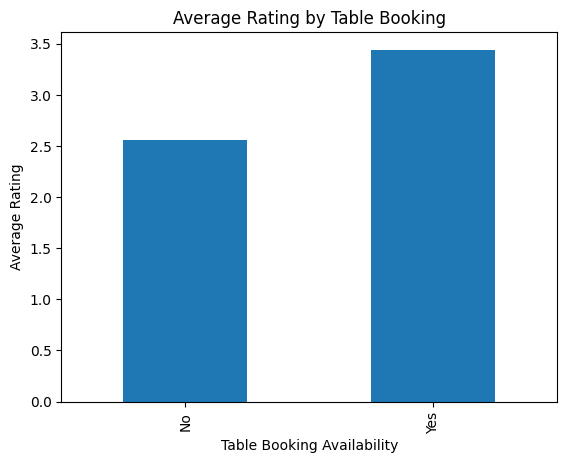

In [32]:
table_rating.plot(kind='bar')

plt.title('Average Rating by Table Booking')
plt.xlabel('Table Booking Availability')
plt.ylabel('Average Rating')
plt.savefig('Average Rating by Table Booking.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
Restaurants that offer table booking have a significantly higher average rating (3.44) compared to restaurants without table booking (2.56). This suggests that table booking services may enhance customer convenience and contribute to better customer satisfaction.

# Online Delivery by Price Range

In [11]:
delivery_price = pd.crosstab(
    df['Price range'],
    df['Has Online delivery'])

print(delivery_price)

Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


### Insight
Online delivery availability varies across different price ranges. Price Range 2 restaurants have the highest number of restaurants offering online delivery (1,286). In contrast, Price Range 4 restaurants have the lowest online delivery availability (53 restaurants). This suggests that online delivery services are more common among affordable and mid-range restaurants than premium restaurants.

## Conclusion and Recommendations

### Key Findings

- 12.12% of restaurants offer table booking services.
- 25.66% of restaurants provide online delivery.
- Restaurants with table booking have a higher average rating (3.44) compared to those without table booking (2.56).
- Online delivery is most common among mid-range restaurants and least common among premium restaurants.

### Recommendations

- Restaurants can improve customer convenience by implementing table booking systems.
- Expanding online delivery services may help restaurants reach more customers.
- Premium restaurants can explore delivery options to increase market reach.
- Future analysis can include cuisine type, location, and customer votes to gain deeper insights into restaurant performance.

# Price Range Analysis
## Most Common Price Range

In [12]:
price_range_count = df['Price range'].value_counts()

print(price_range_count)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


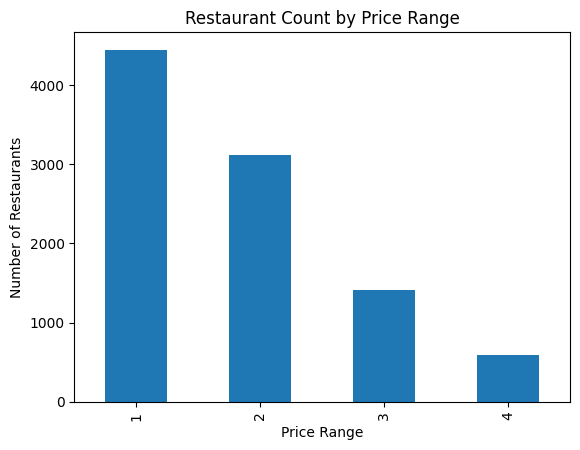

In [33]:
price_range_count.plot(kind='bar')

plt.title('Restaurant Count by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.savefig('Restaurant Count by Price Range.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
Price Range 1 is the most common price category, with 4,444 restaurants. This indicates that the majority of restaurants in the dataset belong to the affordable or budget-friendly segment. As the price range increases, the number of restaurants decreases significantly.

## Average Rating by Price Range

In [15]:
avg_rating = df.groupby('Price range')['Aggregate rating'].mean()
print(avg_rating)

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


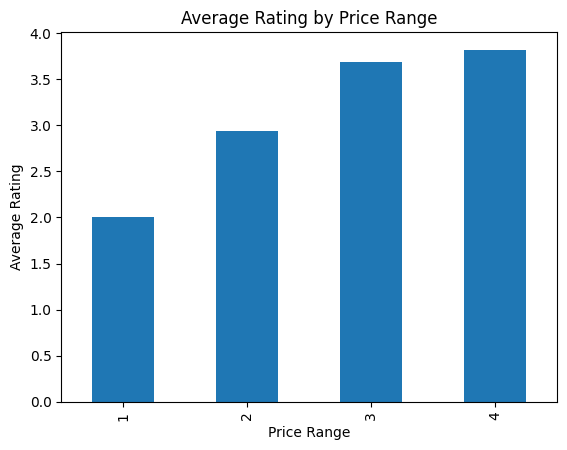

In [34]:
avg_rating.plot(kind='bar')

plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.savefig('Average Rating by Price Range.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
The average restaurant rating increases as the price range increases. Price Range 4 restaurants have the highest average rating (3.82), while Price Range 1 restaurants have the lowest average rating (2.00). This suggests that higher-priced restaurants generally receive better customer ratings, possibly due to better service quality, ambiance, and dining experience.

# Color Representing Highest Average Rating

In [17]:
color_rating = df.groupby('Rating color')['Aggregate rating'].mean()

print(color_rating.sort_values(ascending=False))

Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
Orange        3.051619
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64


### Insight
Dark Green represents the highest average rating (4.66) among all rating colors. Restaurants with Dark Green ratings are the best-performing establishments in the dataset, indicating excellent customer satisfaction and service quality.

## Conclusion and Recommendations

### Key Findings

- Price Range 1 is the most common category, with 4,444 restaurants.
- The average rating increases as the price range increases.
- Price Range 4 restaurants have the highest average rating (3.82).
- Dark Green is the rating color associated with the highest average rating (4.66).

### Recommendations

- Restaurant owners should focus on improving service quality and customer experience to achieve higher ratings.
- Budget-friendly restaurants can learn from higher-rated premium restaurants to improve customer satisfaction.
- Customers seeking the best dining experiences may prefer restaurants with Dark Green ratings.
- Future analysis can include cuisine type, location, and customer reviews to better understand rating patterns.

# Feature Engineering
## Length of Restaurant Name

In [19]:
df['Restaurant_Name_Length'] = df['Restaurant Name'].str.len()

print(df[['Restaurant Name',
          'Restaurant_Name_Length']].head())

          Restaurant Name  Restaurant_Name_Length
0        Le Petit Souffle                      16
1        Izakaya Kikufuji                      16
2  Heat - Edsa Shangri-La                      22
3                    Ooma                       4
4             Sambo Kojin                      11


### Insight
This feature measures the length of restaurant names and may be useful for identifying naming patterns among restaurants

# Length of Address

In [20]:
df['Address_Length'] = df['Address'].str.len()
print(df[['Address','Address_Length']].head())

                                             Address  Address_Length
0  Third Floor, Century City Mall, Kalayaan Avenu...              71
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...              67
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...              56
3  Third Floor, Mega Fashion Hall, SM Megamall, O...              70
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...              64


### Address Length Feature
A new feature called Address_Length was created by calculating the number of characters in each restaurant's address. This converts text data into a numerical format that can be used for analysis and machine learning models.

# Encode "Has Table Booking"

In [21]:
df['Table_Booking_Encoded'] = df['Has Table booking'].map({
    'No':0,
    'Yes':1})
print(df[['Has Table booking','Table_Booking_Encoded']].head())

  Has Table booking  Table_Booking_Encoded
0               Yes                      1
1               Yes                      1
2               Yes                      1
3                No                      0
4               Yes                      1


### Insight
The Online_Delivery_Encoded feature was created by converting "Yes" values to 1 and "No" values to 0. This numerical representation makes the online delivery feature easier to analyze and use in predictive models.

## Conclusion and Recommendations

### Key Findings

- New features were created from existing columns to improve the dataset.
- Restaurant name length and address length were extracted as numerical features.
- Table booking and online delivery information were converted into binary numerical values.
- These engineered features make the dataset more suitable for machine learning and advanced analytics.

### Recommendations

- Feature engineering improves data quality and model performance.
- Encoded variables can be directly used in predictive models.
- Additional features such as cuisine count, city encoding, and rating categories can further enhance analysis.

# Final Project Summary

This project analyzed restaurant data using Python, Pandas, Matplotlib, and Seaborn. The analysis explored restaurant ratings, locations, cuisines, pricing, table booking availability, online delivery services, and feature engineering techniques.

Key findings showed that:
- Price Range 1 restaurants are the most common.
- Higher price ranges generally receive better ratings.
- Restaurants offering table booking tend to have higher ratings.
- Online delivery is most common among mid-range restaurants.
- Dark Green restaurants have the highest average ratings.

The project demonstrates data cleaning, exploratory data analysis, visualization, and feature engineering skills.